In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set the visual parameters
sc.settings.set_figure_params(
    dpi = 200,
    facecolor='white',
    frameon=False
)

In [2]:
visit_keep = ["PreTx", "Healthy"]

adata_bmmc = sc.read_h5ad("../../data/figure-inputs/scrna_objects/final-bmmc-processed.h5ad")
adata_bmmc = adata_bmmc[adata_bmmc.obs["label.visitDetails"].isin(visit_keep)].copy()

adata_pbmc = sc.read_h5ad("../../data/figure-inputs/scrna_objects/final-pbmc-raw.h5ad")
adata_pbmc = adata_pbmc[adata_pbmc.obs["label.visitDetails"].isin(visit_keep)].copy()
sc.pp.normalize_total(adata_pbmc)
sc.pp.log1p(adata_pbmc)

adata = adata_bmmc.concatenate(adata_pbmc, batch_key="tissue", batch_categories=["BMMC", "PBMC"])

/tmp/ipykernel_77031/3973431154.py:11: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_bmmc.concatenate(adata_pbmc, batch_key="tissue", batch_categories=["BMMC", "PBMC"])


/home/workspace/environment/ndmm-scrna/lib/python3.11/site-packages/anndata/_core/merge.py:1410: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  warn(


In [3]:
# Align plasma cell names
adata.obs["aifi_plot_l2"] = adata.obs["aifi_plot_l2"].astype(str)
adata.obs["aifi_plot_l2"] = adata.obs["aifi_plot_l2"].replace("Plasma (Non-malignant)", "Plasma_Normal")
adata.obs["aifi_plot_l2"] = adata.obs["aifi_plot_l2"].replace("Plasma", "Plasma_Normal")
adata.obs["aifi_plot_l2"] = adata.obs["aifi_plot_l2"].replace("Plasma (Malignant)", "Plasma_Tumor")

adata.obs["group"] = (
    adata.obs["tissue"].astype(str)
    + "_"
    + adata.obs["aifi_plot_l2"].astype(str)
    + "_"
    + adata.obs["label.visitDetails"].astype(str)
)

tissues = adata.obs["tissue"].unique().tolist()
visits = adata.obs["label.visitDetails"].unique().tolist()

In [4]:
celltypes_ordered = ["Plasma_Normal", "Plasma_Tumor"]

adata_sub = adata[adata.obs["aifi_plot_l2"].isin(celltypes_ordered)].copy()

group_order = [
    f"{t}_{ct}_{v}"
    for t in tissues
    for ct in celltypes_ordered
    for v in visits
    if f"{t}_{ct}_{v}" in adata.obs["group"].values
]

adata_sub.obs["group"] = adata_sub.obs["group"].astype("category")
adata_sub.obs["group"] = adata_sub.obs["group"].cat.set_categories(group_order, ordered=True)

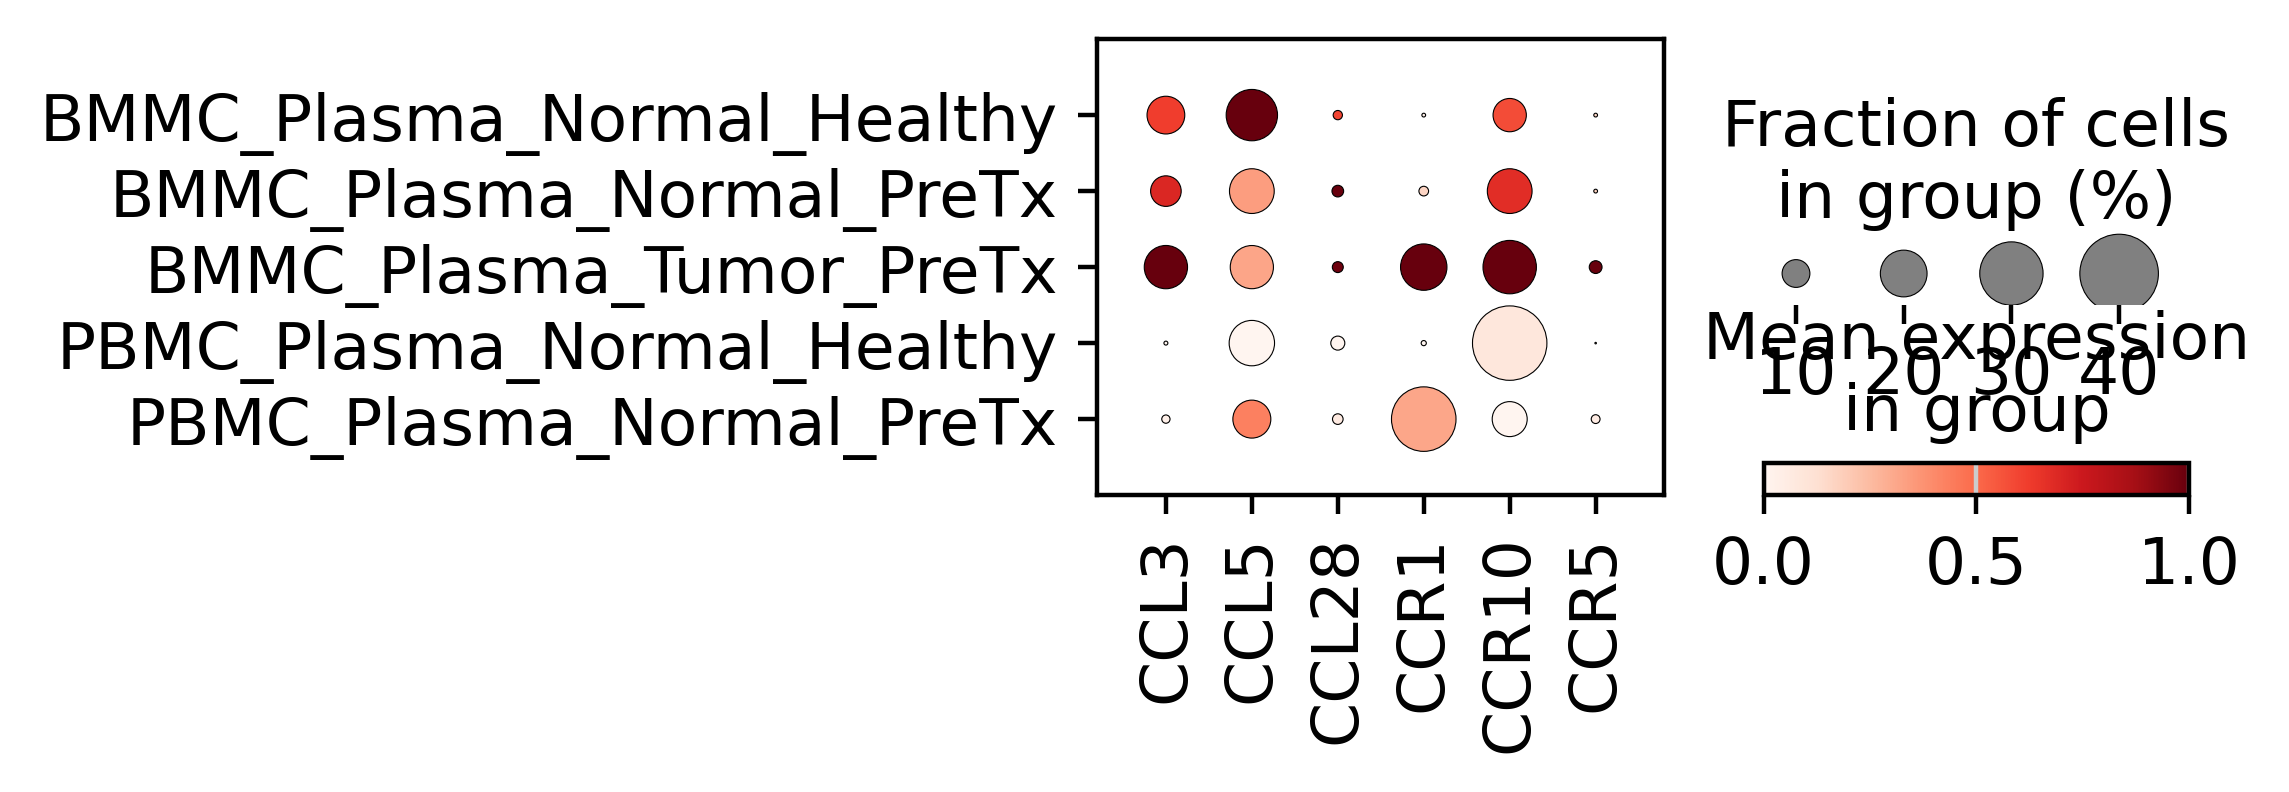

In [5]:
genes = ["CCL3", "CCL5", "CCL28", "CCR1", "CCR10", "CCR5"]

plt.rcParams["pdf.fonttype"] = 42
sc.pl.dotplot(
    adata_sub,
    var_names=genes,
    groupby="group",
    standard_scale="var",
    use_raw=False,
    dendrogram=False,
    swap_axes=False,
    show=False,
    figsize=(3.5, 1.5),
)

plt.savefig("../../data/figure-outputs/figure-2/fig_2m.pdf", dpi=200, bbox_inches="tight")